### Vergleich quantisierter und nicht quantisierter Modelle

Der Vergleich erfolgt üblicherweise über drei Bereiche:

1. **Genauigkeit**
   - Bewertung der Top-1/Top-5-Accuracy oder anderer relevanter Metriken.
   - Messung auf identischen Testdaten, um den Einfluss der Quantisierung isoliert zu betrachten.

2. **Performanz**
   - Vergleich von Latenz, Durchsatz und Speicherverbrauch.
   - Quantisierte Modelle benötigen weniger Speicher und sind oft schneller, besonders auf Hardware mit INT-Optimierungen.

3. **Robustheit und Erklärbarkeit**
   - Analyse identischer Eingaben mit Methoden wie ScoreCAM, SHAP oder LIME.
   - Untersuchung, ob die quantisierte Version ähnliche Entscheidungsregionen und Erklärungen liefert wie das ursprüngliche Modell.



### Imports
Das Paket muss mit pip install -e . installiert werden (im Hauptverzeichnis), falls dies noch nicht gemacht wurde. #!pip install -e . kann bei Bedarf auskommentiert werden.

In [1]:
#!pip install -e .
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


from maco_package.quantization import *
from maco_package.utils import *
from maco_package.data import *
from maco_package.visualization import *
from maco_package.xai import *
from maco_package.compare import *

/home/neli/.local/share/mamba/envs/Master/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Zum verlgeich sollten alle Modelle auf dem sleben device geladen werden da nur cpu möglich bei quantisierten alle auf cpu

Label: prairie chicken, prairie grouse, prairie fowl


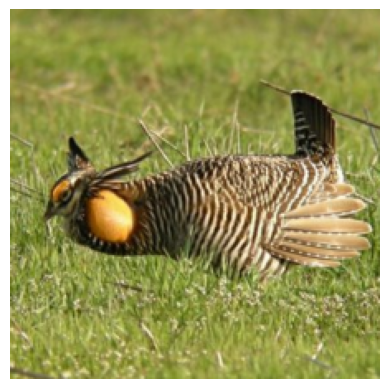

In [2]:
ROOT = "../data/imagenet100/versions/8"
train_dataset, val_dataset, class_to_idx = build_datasets(ROOT)
NUM_CLASSES = len(class_to_idx)
synset_to_name = load_class_names(ROOT)
img = show_random_sample(train_dataset, class_to_idx, synset_to_name,return_sample=True)

In [3]:
resnet50_finetuned = load_model(
    path="../saved_models/resnet50_finetuned.pth",
    num_classes=NUM_CLASSES,
    device="cuda"
)
resnet50_qatfake = load_resnet50_qatfake(
    "../saved_models/resnet50_qatfake.pth",
    num_classes=NUM_CLASSES,
    device="cuda"
)
model_int8_qat =  load_resnet50_qat_int8(
    "../saved_models/resnet50_qat_int8.pth",
    num_classes=NUM_CLASSES,
    device="cpu"
)
model_int8_ptq = load_resnet50_ptq_fx_state(
    "../saved_models/resnet50_ptq.pth",
    num_classes=NUM_CLASSES,
    device="cpu"
)

In [7]:
import torch
from torch.utils.data import DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

acc_finetuned = evaluate_top1(resnet50_finetuned, val_loader, "cuda")
acc_qatfake   = evaluate_top1(resnet50_qatfake, val_loader, "cuda")
acc_qat_int8  = evaluate_top1(model_int8_qat,   val_loader, "cpu")
acc_ptq_int8  = evaluate_top1(model_int8_ptq,   val_loader, "cpu")


print("Top-1 Accuracy:")
print(f"Finetuned FP32     : {acc_finetuned:.4f}")
print(f"QAT FakeQuant (FP32): {acc_qatfake:.4f}")
print(f"QAT INT8            : {acc_qat_int8:.4f}")
print(f"PTQ INT8            : {acc_ptq_int8:.4f}")



Top-1 Accuracy:
Finetuned FP32     : 0.8670
QAT FakeQuant (FP32): 0.8544
QAT INT8            : 0.8480
PTQ INT8            : 0.8550


==> quantisierte Modelle nehmen an Genauigkeit ab

In [8]:
import torch
from torch.utils.data import DataLoader


perf_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

resnet50_finetuned = resnet50_finetuned.to("cpu")
resnet50_qatfake   = resnet50_qatfake.to("cpu")


lat_finetuned = measure_latency(resnet50_finetuned, perf_loader, "cpu")
lat_qatfake   = measure_latency(resnet50_qatfake,   perf_loader, "cpu")
lat_qat_int8  = measure_latency(model_int8_qat,     perf_loader, "cpu")
lat_ptq_int8  = measure_latency(model_int8_ptq,     perf_loader, "cpu")

thr_finetuned = measure_throughput(resnet50_finetuned, perf_loader, "cpu")
thr_qatfake   = measure_throughput(resnet50_qatfake,   perf_loader, "cpu")
thr_qat_int8  = measure_throughput(model_int8_qat,     perf_loader, "cpu")
thr_ptq_int8  = measure_throughput(model_int8_ptq,     perf_loader, "cpu")

print("\nLatenz (ms/Bild):")
print(f"Finetuned FP32     : {lat_finetuned:.2f}")
print(f"QAT FakeQuant (FP32): {lat_qatfake:.2f}")
print(f"QAT INT8            : {lat_qat_int8:.2f}")
print(f"PTQ INT8            : {lat_ptq_int8:.2f}")

print("\nDurchsatz (Bilder/s):")
print(f"Finetuned FP32     : {thr_finetuned:.1f}")
print(f"QAT FakeQuant (FP32): {thr_qatfake:.1f}")
print(f"QAT INT8            : {thr_qat_int8:.1f}")
print(f"PTQ INT8            : {thr_ptq_int8:.1f}")



Latenz (ms/Bild):
Finetuned FP32     : 34.54
QAT FakeQuant (FP32): 114.81
QAT INT8            : 16.28
PTQ INT8            : 16.03

Durchsatz (Bilder/s):
Finetuned FP32     : 26.5
QAT FakeQuant (FP32): 8.5
QAT INT8            : 55.8
PTQ INT8            : 57.4


==> quantisierte Modelle laufen dafür schneller

In [5]:
path_finetuned = "../saved_models/resnet50_finetuned.pth"
path_qatfake   = "../saved_models/resnet50_qatfake.pth"
path_qat_int8  = "../saved_models/resnet50_qat_int8.pth"
path_ptq_int8  = "../saved_models/resnet50_ptq.pth"

print("Modelldateigröße (MB):")
print(f"Finetuned FP32      : {file_size_mb(path_finetuned):.2f} MB")
print(f"QAT FakeQuant FP32  : {file_size_mb(path_qatfake):.2f} MB")
print(f"QAT INT8            : {file_size_mb(path_qat_int8):.2f} MB")
print(f"PTQ INT8            : {file_size_mb(path_ptq_int8):.2f} MB")




Modelldateigröße (MB):
Finetuned FP32      : 90.76 MB
QAT FakeQuant FP32  : 91.10 MB
QAT INT8            : 23.18 MB
PTQ INT8            : 23.18 MB


==> und sind kleiner

## Vergleichsmetriken für erklärbare Methoden


### 1. CAM-basierte Methoden (ScoreCAM, EigenCAM, GradCAM)



#### **SSIM (Structural Similarity Index)**
Misst strukturelle Ähnlichkeit zweier Heatmaps hinsichtlich Helligkeit, Kontrast und lokalen Mustern.  

#### **Korrelation (Pearson)**
Erfasst die lineare Beziehung zwischen den Intensitäten beider Heatmaps.  

#### **Dice-Koeffizient**
Misst die Überlappung der am stärksten aktivierten Regionen.  

#### **IoU (Intersection-over-Union)**
Verhältnis aus Schnittmenge zu Vereinigungsmenge der relevanten Bereiche.  
Bewertet die räumliche Übereinstimmung.

#### **EMD (Earth Mover’s Distance)**
Quantifiziert, wie weit Aktivierungsmassen räumlich verschoben sind.  
Niedrige Werte bedeuten nahezu gleiche räumliche Fokussierung.

#### **JS-Divergenz (Jensen–Shannon)**
Vergleicht die Verteilungen der Heatmap-Intensitäten.  

### 2. SHAP-Erklärungen

#### **Spearman Rank-Korrelation**
Vergleicht die Rangordnung der superpixelbasierten Relevanzwerte.  
Misst, ob beide Modelle dieselben Regionen als wichtig einstufen.

#### **Sign-Agreement**
Prozentualer Anteil der Regionen, bei denen beide Modelle das gleiche Vorzeichen aufweisen

#### **Top-k-Overlap**
Jaccard-Überlappung der k% wichtigsten Regionen



### 3. LIME-Erklärungen


#### **IoU (Superpixel-Overlap)**
Überlappung der relevanten Superpixel beider Modelle.

#### **Precision**
Anteil der von INT8 als relevant markierten Regionen, die auch im FP32-Modell relevant sind.

#### **Recall**
Anteil der FP32-relevanten Regionen, die durch das quantisierte Modell wiedererkannt werden.

#### **Agreement**
Gesamtanteil aller Pixel, bei denen beide Modelle denselben Wichtigkeitsstatus haben.




In [16]:
layer = "layer4.2.conv3"

cam_base = compute_eigencam(resnet50_finetuned, img, layer, plot=False, return_map=True)
cam_fake = compute_eigencam(resnet50_qatfake,   img, layer, plot=False, return_map=True)
cam_qat  = compute_eigencam(model_int8_qat,     img, layer, plot=False, return_map=True)
cam_ptq  = compute_eigencam(model_int8_ptq,     img, layer, plot=False, return_map=True)

res_fake = compare_cams_advanced(cam_base, cam_fake)
res_qat  = compare_cams_advanced(cam_base, cam_qat)
res_ptq  = compare_cams_advanced(cam_base, cam_ptq)

print("FakeQuant vs FP32:", res_fake)
print("QAT INT8 vs FP32 :", res_qat)
print("PTQ INT8 vs FP32 :", res_ptq)

FakeQuant vs FP32: {'ssim': 0.6154604567395722, 'corr': 0.6910243103484247, 'dice': 0.6965118646621704, 'iou': 0.5343446135520935, 'emd': 0.10308757799793039, 'js': 0.26158756017684937}
QAT INT8 vs FP32 : {'ssim': 0.8211422615167838, 'corr': 0.940157465910962, 'dice': 0.7576631903648376, 'iou': 0.6098693609237671, 'emd': 0.053370498381691424, 'js': 0.14762280881404877}
PTQ INT8 vs FP32 : {'ssim': 0.908120878238484, 'corr': 0.9298529061609118, 'dice': 0.8761062026023865, 'iou': 0.7795275449752808, 'emd': 0.026567143220518116, 'js': 0.11922028660774231}


In [7]:
shap_base = compute_shap(resnet50_finetuned, img, plot=False,  return_values=True)
shap_qat  = compute_shap(model_int8_qat,     img, plot=False,  return_values=True)
shap_ptq  = compute_shap(model_int8_ptq,     img, plot=False,  return_values=True)

res_qat = compare_shap(shap_base, shap_qat)
res_ptq = compare_shap(shap_base, shap_ptq)

print("SHAP QAT vs FP32:", res_qat)
print("SHAP PTQ vs FP32:", res_ptq)

SHAP QAT vs FP32: {'spearman': 0.5050462263923374, 'sign_agreement': 0.796875, 'topk_overlap': 0.3713700034163828}
SHAP PTQ vs FP32: {'spearman': 0.5518186086076129, 'sign_agreement': 0.734375, 'topk_overlap': 0.37635440954592964}


In [8]:
lime_base = compute_lime(resnet50_finetuned, img, plot=False,  return_mask=True)
lime_qat  = compute_lime(model_int8_qat, img, plot=False,  return_mask=True)
lime_ptq  = compute_lime(model_int8_ptq, img, plot=False,  return_mask=True)

res_qat = compare_lime(lime_base, lime_qat)
res_ptq = compare_lime(lime_base, lime_ptq)

print("LIME QAT vs FP32:", res_qat)
print("LIME PTQ vs FP32:", res_ptq)


100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 72.07it/s]

LIME QAT vs FP32: {'iou': 0.30556701030902633, 'precision': 0.5312589618575692, 'recall': 0.4183604336038636, 'agreement': 0.8321906887755102}
LIME PTQ vs FP32: {'iou': 0.5123489227530983, 'precision': 0.6954350927238523, 'recall': 0.6605691056903109, 'agreement': 0.889030612244898}


FakeQuant ist erwartbar das am weitest entfernte modell PTQ ist ähnlicher zum basis modell als QAT was vermutlich auf einen Fehler im Training (zu wening epochen oder was schlimmeres idk) hinweist

UMAP-Merkmalsanalyse nutzt die Aktivierungen eines Layers, um die hochdimensionalen Feature-Vektoren eines Modells in eine zweidimensionale Darstellung zu überführen. Dadurch wird sichtbar, wie ein Modell seine Eingaben intern strukturiert und welche Cluster oder Klassenabstände entstehen.

Indem die Feature-Vektoren verschiedener Modellvarianten (FP32, QAT, PTQ) gemeinsam eingebettet werden, lässt sich direkt erkennen, wie ähnlich oder unterschiedlich ihre internen Repräsentationen sind. Das zeigt, ob Quantisierung die Merkmalsstruktur verändert oder weitgehend erhält.

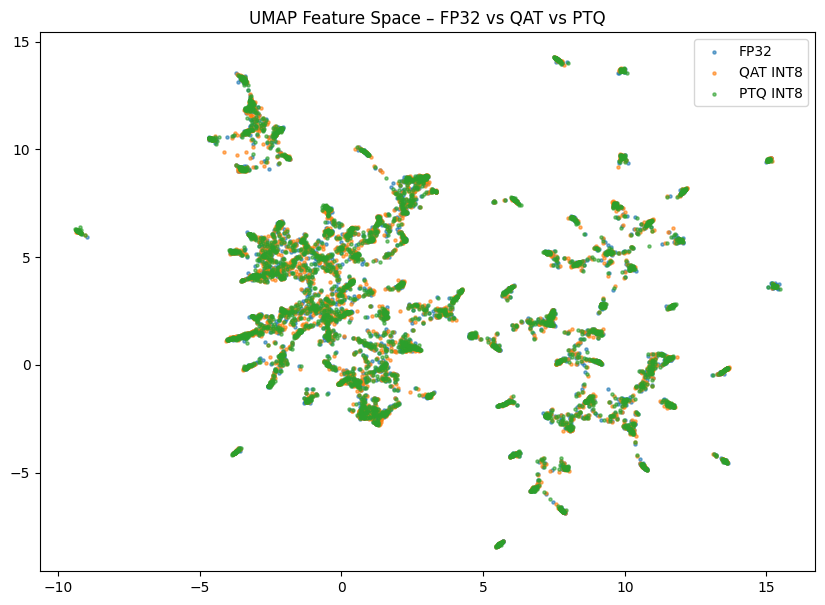

In [4]:
batch_size = 32
loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

feats_fp32, labels_fp32 = extract_features2(resnet50_finetuned, loader)
feats_qat,  labels_qat  = extract_features2(model_int8_qat,      loader)
feats_ptq,  labels_ptq  = extract_features2(model_int8_ptq,      loader)

run_umap_visualization(feats_fp32, feats_qat, feats_ptq, labels_fp32)


Alle 3 Modelle erzeugen ähnliche Feature-Repräsentationen was klar ist da nur quantisiert. aber auch hier sieht man das QAT Modell weicht weiter vom base Modell ab als das PTQ Modell ==> irgendwas ist schiefgelaufen

In [ ]:
results = compute_class_shifts(feats_fp32, feats_qat, feats_ptq, labels_fp32 )
idx_to_name = {
    idx: synset_to_name[synset]
    for synset, idx in class_to_idx.items()
}
for c, m in sorted(results.items()):
    class_name = idx_to_name[c]
    print(
        f"{class_name}: "
        f"mean_L2 QAT={m['mean_L2_FP32_vs_QAT']:.4f}, "
        f"mean_L2 PTQ={m['mean_L2_FP32_vs_PTQ']:.4f}"
    )

In [12]:
# Best and worst for QAT
best_qat_class  = min(results, key=lambda c: results[c]["mean_L2_FP32_vs_QAT"])
worst_qat_class = max(results, key=lambda c: results[c]["mean_L2_FP32_vs_QAT"])

# Best and worst for PTQ
best_ptq_class  = min(results, key=lambda c: results[c]["mean_L2_FP32_vs_PTQ"])
worst_ptq_class = max(results, key=lambda c: results[c]["mean_L2_FP32_vs_PTQ"])


In [15]:
mean_qat_shift = np.mean([m["mean_L2_FP32_vs_QAT"] for m in results.values()])
mean_ptq_shift = np.mean([m["mean_L2_FP32_vs_PTQ"] for m in results.values()])
better_model = "QAT" if mean_qat_shift < mean_ptq_shift else "PTQ"


In [18]:
print("Best QAT class:", idx_to_name[best_qat_class],
      "shift =", results[best_qat_class]["mean_L2_FP32_vs_QAT"])

print("Worst QAT class:", idx_to_name[worst_qat_class],
      "shift =", results[worst_qat_class]["mean_L2_FP32_vs_QAT"])

print("Best PTQ class:", idx_to_name[best_ptq_class],
      "shift =", results[best_ptq_class]["mean_L2_FP32_vs_PTQ"])

print("Worst PTQ class:", idx_to_name[worst_ptq_class],
      "shift =", results[worst_ptq_class]["mean_L2_FP32_vs_PTQ"])

print("QAT mean shift:", mean_qat_shift)
print("PTQ mean shift:", mean_ptq_shift)
print("Better overall model:", better_model)


Best QAT class: black and gold garden spider, Argiope aurantia shift = 5.801970958709717
Worst QAT class: conch shift = 10.089360237121582
Best PTQ class: peacock shift = 2.98811674118042
Worst PTQ class: nematode, nematode worm, roundworm shift = 5.320834159851074
QAT mean shift: 7.957679839134216
PTQ mean shift: 4.078413841724395
Better overall model: PTQ
